# Data Collect

In [8]:
import pandas as pd

data = pd.read_csv("Penjualan Zenius.csv")

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Created at        713 non-null    str  
 1   Package           713 non-null    str  
 2   Price             713 non-null    int64
 3   Commission Value  713 non-null    int64
 4   Invoice           713 non-null    str  
 5   Customer_ID       713 non-null    str  
dtypes: int64(2), str(4)
memory usage: 33.6 KB


# Data Cleaning

### Missing Value

In [10]:
data.isnull().sum()

Created at          0
Package             0
Price               0
Commission Value    0
Invoice             0
Customer_ID         0
dtype: int64

### Formatting

In [11]:
data["Created at"] = pd.to_datetime(data["Created at"])
data["Price"] = data["Price"].astype(int)
data["Commission Value"] = data["Commission Value"].astype(int)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Created at        713 non-null    datetime64[us]
 1   Package           713 non-null    str           
 2   Price             713 non-null    int64         
 3   Commission Value  713 non-null    int64         
 4   Invoice           713 non-null    str           
 5   Customer_ID       713 non-null    str           
dtypes: datetime64[us](1), int64(2), str(3)
memory usage: 33.6 KB


### Duplicate Data

In [12]:
data.duplicated().sum()

np.int64(0)

### Data Validation
Mengecek apakah ada price <= 0

In [13]:
data[data["Price"] <= 0]

,Created at,Package,Price,Commission Value,Invoice,Customer_ID


In [14]:
data[data["Commission Value"] <= 0]

,Created at,Package,Price,Commission Value,Invoice,Customer_ID


In [15]:
data.groupby("Package")["Price"].unique()

Package
Paket 1 Bulan     [175000]
Paket 12 Bulan    [450000]
Paket 3 Bulan     [225000]
Paket 6 Bulan     [335000]
Paket 9 Bulan     [425000]
Name: Price, dtype: object

### Outlier

In [16]:
cols = ["Price", "Commission Value"]

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_price = data[(data[col] < lower) | (data[col] > upper)]

    print(f"Outliers in {col}:", outlier_price)

Outliers in Price: Empty DataFrame
Columns: [Created at, Package, Price, Commission Value, Invoice, Customer_ID]
Index: []
Outliers in Commission Value: Empty DataFrame
Columns: [Created at, Package, Price, Commission Value, Invoice, Customer_ID]
Index: []


# Data Understanding

### Descriptive Statistics

In [17]:
data.describe()

,Created at,Price,Commission Value
count,713,713.000000,713.000000
mean,2025-08-10 14:02:11.276297,275308.555400,41296.283310
min,2025-01-29 00:00:00,175000.000000,26250.000000
25%,2025-05-18 00:00:00,175000.000000,26250.000000
50%,2025-08-02 00:00:00,225000.000000,33750.000000
75%,2025-11-03 00:00:00,335000.000000,50250.000000
max,2026-06-19 00:00:00,450000.000000,67500.000000
std,NaN,106018.880274,15902.832041


### Repeat Customer

In [18]:
repeat_customer = data["Customer_ID"].value_counts()
repeat_customer = repeat_customer[repeat_customer > 1]
repeat_customer

Customer_ID
C270    3
C021    2
C031    2
C042    2
C043    2
C078    2
C144    2
C196    2
C222    2
C227    2
C374    2
C435    2
C444    2
C471    2
C511    2
C512    2
C522    2
C525    2
C531    2
Name: count, dtype: int64

Membuat program loyalitas atau diskon khusus untuk pelanggan lama.
Melakukan follow-up kepada pelanggan yang pernah membeli.
Menawarkan paket lanjutan (upselling/cross-selling) kepada pelanggan yang sudah pernah bertransaksi.

### Commission by Package

In [19]:
data["Commission Rate"] = (
    data["Commission Value"] / data["Price"]
) * 100
data["Commission Rate"].value_counts()

Commission Rate
15.0    713
Name: count, dtype: int64

### Best-Seliing Packages

In [21]:
data["Package"].value_counts()

Package
Paket 1 Bulan     229
Paket 3 Bulan     220
Paket 12 Bulan    130
Paket 6 Bulan      97
Paket 9 Bulan      37
Name: count, dtype: int64

In [22]:
package_revenue = (
    data.groupby("Package")["Price"]
    .sum()
    .sort_values(ascending=False)
)

package_revenue

Package
Paket 12 Bulan    58500000
Paket 3 Bulan     49500000
Paket 1 Bulan     40075000
Paket 6 Bulan     32495000
Paket 9 Bulan     15725000
Name: Price, dtype: int64

In [ ]:
package_commission = (
    data.groupby("Package")["Commission Value"]
    .sum()
    .sort_values(ascending=False)
)

package_commission

Package
Paket 12 Bulan    8775000
Paket 3 Bulan     7425000
Paket 1 Bulan     6011250
Paket 6 Bulan     4874250
Paket 9 Bulan     2358750
Name: Commission Value, dtype: int64

### Sales Trend

In [312]:
data["Month"] = data["Created at"].dt.month
data["Month_Name"] = data["Created at"].dt.strftime("%B")

In [313]:
monthly_sales = (
    data.groupby("Month_Name", observed=True)
    .size()
    .reset_index(name="Total_Transaction")
)

monthly_sales

,Month_Name,Total_Transaction
0,April,50
1,August,107
2,December,40
3,February,63
4,January,70
5,July,78
6,June,90
7,March,85
8,May,31
9,November,25


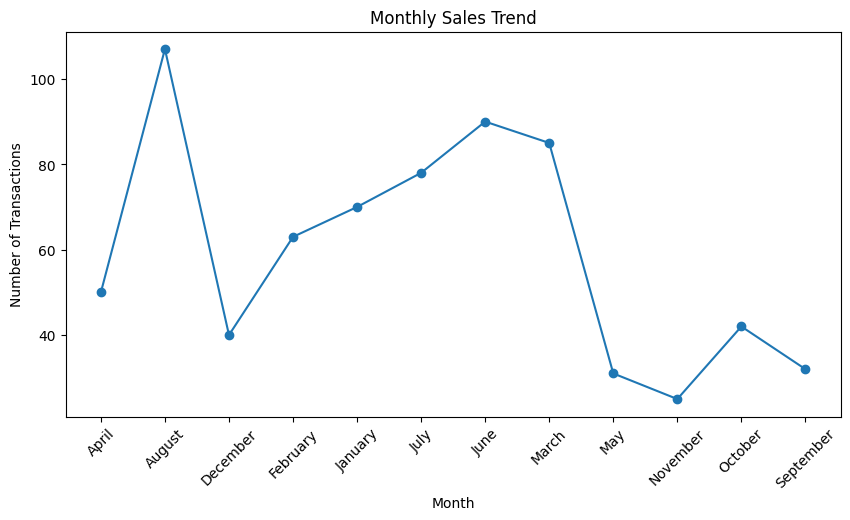

In [314]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales["Month_Name"],
    monthly_sales["Total_Transaction"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

In [315]:
monthly_revenue = (
    data.groupby("Month_Name", observed=True)["Price"]
    .sum()
    .reset_index(name="Revenue")
)

monthly_revenue

,Month_Name,Revenue
0,April,11230000
1,August,36885000
2,December,10130000
3,February,15020000
4,January,16845000
5,July,28320000
6,June,23795000
7,March,16570000
8,May,8175000
9,November,7525000
